# Phase 2 — Data Pipeline

Goals: a fixed, reproducible train/val/test split; a PyTorch `Dataset` +
`DataLoader`; transforms (resize, augmentation, normalization); per-class training
weights. Everything here is cached to disk and reused unchanged by every later phase
-- that's what makes the Phase 8 comparison meaningful.

Carried over from Phase 1's EDA: a 36x class imbalance (drives the per-class weights
below) and one stray RGBA image among 54,304 RGB images (drives the `.convert("RGB")`
in `PlantDiseaseDataset`).

In [13]:
# Colab only: mount Drive and cd into the synced project folder.
# Safe to run locally too -- the import fails there and this cell is skipped.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd "/content/drive/MyDrive/Colab Notebooks/Plant_Disease_Classification_Project"
except ImportError:
    pass

In [14]:
import sys, os

# Walk up from cwd to the project root (marked by configs/config.yaml) and put it on
# sys.path. Plain os.getcwd() isn't reliable here -- it depends on how the kernel was
# launched (VS Code's Jupyter extension defaults to the notebook's own folder, not the
# project root, which differs from how this ran on Linux before).
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "configs", "config.yaml")):
    _parent = os.path.dirname(_root)
    if _parent == _root:
        raise RuntimeError("Could not find project root (configs/config.yaml) above " + os.getcwd())
    _root = _parent
sys.path.append(_root)

import pandas as pd
import matplotlib.pyplot as plt

from src.utils.config import load_config
from src.data.fetch_data import fetch_dataset
from src.data import splits, transforms as T, dataset as D

cfg = load_config()
print("Environment:", cfg["env"])

fetch_dataset(cfg)  # no-op if already downloaded
DATA_PATH = cfg["data"]["path"]
ARTIFACTS_DIR = cfg["data"]["artifacts_dir"]
DATA_PATH, ARTIFACTS_DIR

Environment: local
Dataset already present at D:\Diljith_A_K\dataset\PlantVillage\color (38 class folders). Skipping download.


('D:\\Diljith_A_K\\dataset\\PlantVillage\\color',
 'G:\\My Drive\\Colab Notebooks\\Plant_Disease_Classification_Project\\experiments\\data')

In [15]:
# Chart color tokens -- same convention as notebooks/01_eda.ipynb
COLOR_PRIMARY = "#2a78d6"
COLOR_SECONDARY = "#eb6834"
COLOR_TERTIARY = "#1baf7a"
COLOR_GRID = "#e1e0d9"
COLOR_AXIS = "#c3c2b7"
COLOR_TEXT = "#0b0b0b"
COLOR_TEXT_MUTED = "#52514e"

## 1. Build the fixed split

Per-class shuffle + split (not a single global shuffle) so the 70/15/15 ratio holds
within every class despite the 36x imbalance found in Phase 1. Cached to
`experiments/data/splits.csv` -- every later phase loads this same file rather than
recomputing a split.

In [16]:
splits_df = splits.build_splits(
    DATA_PATH, cfg["split"], cfg["seed"], cache_path=f"{ARTIFACTS_DIR}/splits.csv"
)
class_to_idx = splits.build_class_to_idx(
    DATA_PATH, cache_path=f"{ARTIFACTS_DIR}/class_to_idx.json"
)

assert splits_df["path"].is_unique, "a file appears more than once in the split"
assert len(splits_df) == splits_df.groupby("class").size().sum()

print(f"Total images: {len(splits_df)} | Classes: {len(class_to_idx)}")
splits_df["split"].value_counts()

Total images: 54305 | Classes: 38


split
train    38012
test      8147
val       8146
Name: count, dtype: int64

## 2. Per-class split proportions

Sanity check that the per-class split actually kept ratios consistent across classes
-- not just in aggregate.

In [17]:
per_class = splits_df.groupby(["class", "split"]).size().unstack(fill_value=0)
per_class["total"] = per_class.sum(axis=1)
per_class["train_pct"] = (per_class["train"] / per_class["total"] * 100).round(1)

print("train_pct across classes -- should cluster tightly around 70%:")
print(per_class["train_pct"].describe())
per_class.sort_values("total").head()

train_pct across classes -- should cluster tightly around 70%:
count    38.000000
mean     69.992105
std       0.063167
min      69.700000
25%      70.000000
50%      70.000000
75%      70.000000
max      70.100000
Name: train_pct, dtype: float64


split,test,train,val,total,train_pct
class,,,,,
Potato___healthy,23,106,23,152,69.7
Apple___Cedar_apple_rust,42,192,41,275,69.8
Peach___healthy,54,252,54,360,70.0
Raspberry___healthy,55,260,56,371,70.1
Tomato___Tomato_mosaic_virus,56,261,56,373,70.0


## 3. Datasets & DataLoaders

In [ ]:
train_transform = T.get_train_transforms(cfg)
eval_transform = T.get_eval_transforms(cfg)

loaders = D.make_dataloaders(
    splits_df,
    class_to_idx,
    train_transform,
    eval_transform,
    batch_size=cfg["dataloader"]["batch_size"],
    num_workers=cfg["dataloader"]["num_workers"],
    data_path=DATA_PATH,
)

for split, loader in loaders.items():
    print(f"{split}: {len(loader.dataset)} images, {len(loader)} batches")

train_xb, train_yb = next(iter(loaders["train"]))
print("\ntrain batch:", train_xb.shape, train_xb.dtype, "| labels:", train_yb.shape, train_yb.dtype)

val_xb, val_yb = next(iter(loaders["val"]))
print("val batch:  ", val_xb.shape, val_xb.dtype)

### The Phase 1 RGBA outlier, loaded explicitly

Proof the `.convert("RGB")` fix works on the exact file, not just luck of random
batch sampling above.

In [19]:
import pandas as pd

In [ ]:
manifest = pd.read_csv(f"{cfg['logging']['experiments_dir']}/eda/manifest.csv")
rgba_path = manifest[manifest["mode"] == "RGBA"]["path"].iloc[0]

idx = splits_df.index[splits_df["path"] == rgba_path][0]
ds = D.PlantDiseaseDataset(splits_df, class_to_idx, data_path=DATA_PATH, transform=eval_transform)
img, label = ds[idx]

print(f"Loaded OK: {rgba_path}")
print(f"Shape: {tuple(img.shape)} | dtype: {img.dtype} | label: {label}")

## 4. Visualize a batch -- train (augmented) vs. eval (no augmentation)

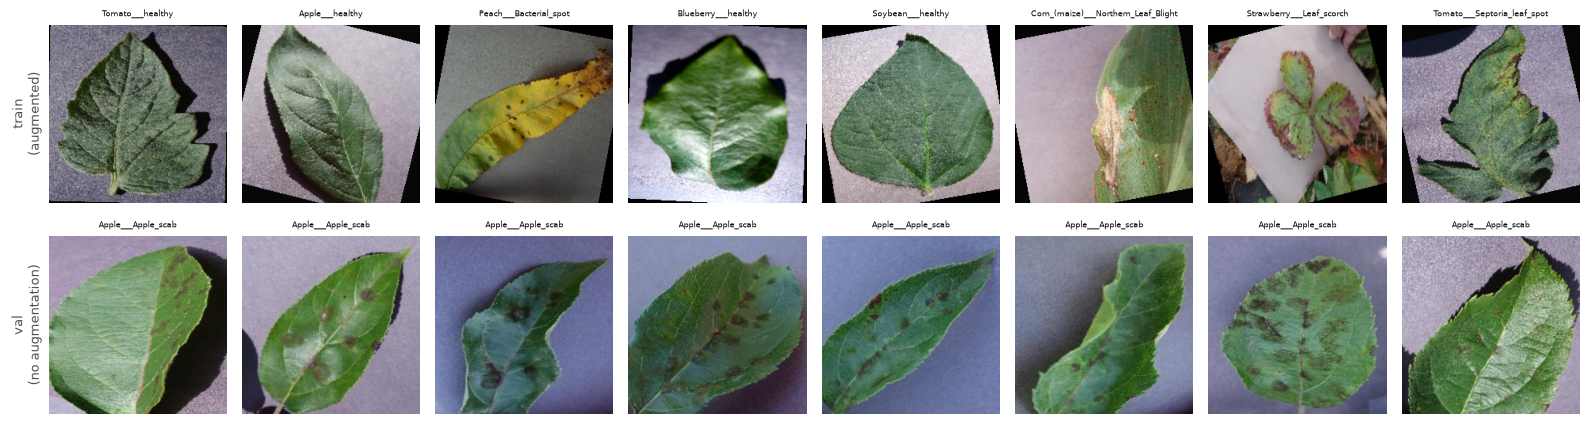

In [21]:
idx_to_class = {v: k for k, v in class_to_idx.items()}
n_show = 8

fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2, 4.5))

for i in range(n_show):
    img = T.denormalize(train_xb[i], cfg).permute(1, 2, 0).numpy()
    axes[0, i].imshow(img)
    axes[0, i].set_title(idx_to_class[train_yb[i].item()], fontsize=6, color=COLOR_TEXT)
    axes[0, i].axis("off")

for i in range(n_show):
    img = T.denormalize(val_xb[i], cfg).permute(1, 2, 0).numpy()
    axes[1, i].imshow(img)
    axes[1, i].set_title(idx_to_class[val_yb[i].item()], fontsize=6, color=COLOR_TEXT)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("train\n(augmented)", fontsize=9, color=COLOR_TEXT_MUTED)
axes[1, 0].set_ylabel("val\n(no augmentation)", fontsize=9, color=COLOR_TEXT_MUTED)
for ax in (axes[0, 0], axes[1, 0]):
    ax.axis("on")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

## 5. Per-class training weights

Inverse-frequency weights computed from the train split only. Phase 3 decides how to
apply these (weighted loss and/or `WeightedRandomSampler`) -- this is just the input
to that decision.

In [22]:
train_df = splits_df[splits_df["split"] == "train"]
class_weights = D.compute_class_weights(train_df, class_to_idx)

weight_series = pd.Series(
    {idx_to_class[i]: w.item() for i, w in enumerate(class_weights)}
).sort_values()

print("Lowest weight (most common classes):")
print(weight_series.head())
print("\nHighest weight (rarest classes):")
print(weight_series.tail())

Lowest weight (most common classes):
Orange___Haunglongbing_(Citrus_greening)    0.142591
Tomato___Tomato_Yellow_Leaf_Curl_Virus      0.146584
Soybean___healthy                           0.154277
Peach___Bacterial_spot                      0.341847
Tomato___Bacterial_spot                     0.369167
dtype: float64

Highest weight (rarest classes):
Tomato___Tomato_mosaic_virus    2.106090
Raspberry___healthy             2.114190
Peach___healthy                 2.181307
Apple___Cedar_apple_rust        2.862966
Potato___healthy                5.185749
dtype: float64


## Summary & implications for Phase 3

In [23]:
print(f"Split cached at: {ARTIFACTS_DIR}/splits.csv")
print(f"class_to_idx cached at: {ARTIFACTS_DIR}/class_to_idx.json")
print(f"Train/val/test sizes: {dict(splits_df['split'].value_counts())}")
print(f"Per-class train_pct range: {per_class['train_pct'].min()}% - {per_class['train_pct'].max()}%")
print(f"Class weight range: {class_weights.min().item():.3f} - {class_weights.max().item():.3f}")

Split cached at: G:\My Drive\Colab Notebooks\Plant_Disease_Classification_Project\experiments\data/splits.csv
class_to_idx cached at: G:\My Drive\Colab Notebooks\Plant_Disease_Classification_Project\experiments\data/class_to_idx.json
Train/val/test sizes: {'train': np.int64(38012), 'test': np.int64(8147), 'val': np.int64(8146)}
Per-class train_pct range: 69.7% - 70.1%
Class weight range: 0.143 - 5.186


Takeaways to carry into Phase 3:

- The split is **fixed and cached** (`experiments/data/splits.csv`,
  `experiments/data/class_to_idx.json`) -- Phase 3 onward must load these rather than
  recomputing a split, or later phases stop being comparable.
- Per-class `train_pct` clusters tightly around 70% despite the 36x imbalance --
  the per-class split strategy worked as intended.
- `class_weights` is ready for Phase 3 to plug into `nn.CrossEntropyLoss(weight=...)`
  and/or a `WeightedRandomSampler` -- decide which (or both) once the from-scratch CNN
  baseline in Phase 4 shows how much the imbalance actually hurts minority-class
  recall.
- Train images visibly differ from val images in the grid above (flip/rotation/color
  jitter vs. clean resize) -- augmentation is confirmed wired correctly, not just
  present in code.